<a href="https://colab.research.google.com/github/919chab/stanford-cars-classification/blob/main/%E1%84%86%E1%85%A9%E1%84%83%E1%85%A6%E1%86%AF_%E1%84%89%E1%85%A5%E1%86%AF%E1%84%80%E1%85%A8(%E1%84%8C%E1%85%A5%E1%86%BC%E1%84%8B%E1%85%B3%E1%86%AB).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Kaggle 라이브러리 설치
!pip install kaggle

# kaggle.json 파일 이동 및 권한 설정
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Kaggle에서 Stanford Cars 데이터셋 다운로드
print("===== Kaggle에서 데이터셋 다운로드 시작 =====")
!kaggle datasets download -d jutrera/stanford-car-dataset-by-classes-folder
print("===== 다운로드 완료 =====")

# 압축 해제
print("\n===== 압축 해제 시작 =====")
!unzip -oq stanford-car-dataset-by-classes-folder.zip
print("===== 압축 해제 완료 =====")

# 경로 확인
!ls -l car_data/car_data/

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
===== Kaggle에서 데이터셋 다운로드 시작 =====
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
===== 다운로드 완료 =====

===== 압축 해제 시작 =====
unzip:  cannot find or open stanford-car-dataset-by-classes-folder.zip, stanford

In [ ]:
# 데이터 준비 및 로더 생성

import torch
import torch.nn as nn
import torch.optim as optim
import os
import matplotlib.pyplot as plt
import numpy as np

# torchvision 관련 라이브러리 호출
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision import models
from torch.utils.data import DataLoader

# 데이터 경로 설정
train_dir = 'car_data/car_data/train'
test_dir = 'car_data/car_data/test'

# 이미지 변환
IMG_SIZE = 224
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),

    # RandAugment (구글의 자동 증강 기술)
    transforms.RandAugment(num_ops=2, magnitude=9),

    transforms.ToTensor(),
    normalize,
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

# 데이터셋 생성
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

class_names = train_dataset.classes
print(f"총 학습 데이터 개수: {len(train_dataset)}")
print(f"총 검증 데이터 개수: {len(val_dataset)}")
print(f"총 클래스 개수: {len(class_names)}개")

# DataLoader 생성
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"데이터 준비 완료! Batch Size: {BATCH_SIZE}")

FileNotFoundError: [Errno 2] No such file or directory: 'car_data/car_data/train'

In [ ]:
# main model

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import time
import copy
from tqdm import tqdm # ★ 진행바 라이브러리 추가

# GPU 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cudnn Benchmark 활성화
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

# === 설정 ===
NUM_EPOCHS = 15


# 모델 로드 (EfficientNet-B0)
weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights)

# 마지막 레이어 수정
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))
model = model.to(device)

# Label Smoothing & AdamW 적용
SMOOTHING_VAL = 0.1
WEIGHT_DECAY = 0.01

criterion = nn.CrossEntropyLoss(label_smoothing=SMOOTHING_VAL)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=WEIGHT_DECAY)

# OneCycleLR 스케줄러
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr=0.001,
    epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.2,
    div_factor=10,
    final_div_factor=100
)

scaler = GradScaler('cuda')

# 학습/검증 함수 (진행바 tqdm 적용)
# epoch 인자를 추가
def train_model(model, train_loader, criterion, optimizer, device, scheduler=None, epoch=0):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # tqdm으로 감싸서 진행바 생성
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train", unit="batch", leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 진행바 옆에 실시간 Loss 표시
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / total, 100 * correct / total

def validate_model(model, val_loader, criterion, device, epoch=0):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # 검증에도 진행바 추가
    progress_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} Valid", unit="batch", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, 100 * correct / total

# 실행 및 데이터 수집
print(f"\n========================================================")
print(f"                    모델 학습 시작                      ")
print(f"========================================================")
print(f" • Device         : {device}")
print(f" • Model          : EfficientNet-B0")
print(f" • Epochs         : {NUM_EPOCHS}")
print(f" • Optimizer      : AdamW (Weight Decay: {WEIGHT_DECAY})")
print(f" • Loss Function  : CrossEntropy (Label Smoothing: {SMOOTHING_VAL})")
print(f" • Scheduler      : OneCycleLR")
print(f"========================================================\n")

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
learning_rates = []

# 최고 모델 저장용 변수
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # 함수 호출 시 epoch 정보 전달
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device, scheduler=scheduler, epoch=epoch)
    val_loss, val_acc = validate_model(model, val_loader, criterion, device, epoch=epoch)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    learning_rates.append(optimizer.param_groups[0]['lr'])

    # Best Model 갱신 여부 확인 및 메시지
    is_best = val_acc > best_acc
    if is_best:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        save_msg = f"🏆 New Best! ({best_acc:.2f}%)"
    else:
        save_msg = f"   (Best: {best_acc:.2f}%)"

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Time: {int(epoch_mins)}m {int(epoch_secs)}s | LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"    └─ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"    └─ Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%  <-- {save_msg}")

print(f"\n========================================================")
print(f" 🎉 학습 완료! 최종 최고 정확도: {best_acc:.2f}%")
print(f"========================================================")

# 최고 성능 모델 저장
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_model.pth')
print("최고 성능 모델이 'best_model.pth'로 저장되었습니다.")


                    모델 학습 시작                      
 • Device         : cuda
 • Model          : EfficientNet-B0
 • Epochs         : 15
 • Optimizer      : AdamW (Weight Decay: 0.01)
 • Loss Function  : CrossEntropy (Label Smoothing: 0.1)
 • Scheduler      : OneCycleLR



Epoch 01/15 | Time: 4m 0s | LR: 0.000326
    └─ Train Loss: 5.1245 | Train Acc: 3.99%
    └─ Val   Loss: 4.4617 | Val   Acc: 15.50%  <-- 🏆 New Best! (15.50%)


Epoch 02/15 | Time: 2m 13s | LR: 0.000777
    └─ Train Loss: 3.4435 | Train Acc: 34.14%
    └─ Val   Loss: 2.4291 | Val   Acc: 53.97%  <-- 🏆 New Best! (53.97%)


Epoch 03/15 | Time: 2m 12s | LR: 0.001000
    └─ Train Loss: 2.1001 | Train Acc: 64.54%
    └─ Val   Loss: 1.9395 | Val   Acc: 68.47%  <-- 🏆 New Best! (68.47%)


Epoch 04/15 | Time: 2m 13s | LR: 0.000983
    └─ Train Loss: 1.6632 | Train Acc: 78.06%
    └─ Val   Loss: 1.6891 | Val   Acc: 77.40%  <-- 🏆 New Best! (77.40%)


...

Epoch 11/15 | Time: 2m 11s | LR: 0.000250
    └─ Train Loss: 0.9858 | Train Acc: 99.15%
    └─ Val   Loss: 1.2845 | Val   Acc: 89.42%  <-- 🏆 New Best! (89.42%)


Epoch 12/15 | Time: 2m 11s | LR: 0.000147
    └─ Train Loss: 0.9716 | Train Acc: 99.29%
    └─ Val   Loss: 1.2782 | Val   Acc: 89.83%  <-- 🏆 New Best! (89.83%)


Epoch 13/15 | Time: 2m 12s | LR: 0.000067
    └─ Train Loss: 0.9572 | Train Acc: 99.56%
    └─ Val   Loss: 1.2767 | Val   Acc: 89.75%  <--    (Best: 89.83%)


Epoch 14/15 | Time: 2m 11s | LR: 0.000018
    └─ Train Loss: 0.9511 | Train Acc: 99.58%
    └─ Val   Loss: 1.2764 | Val   Acc: 89.83%  <--    (Best: 89.83%)


Epoch 15/15 | Time: 2m 13s | LR: 0.000001
    └─ Train Loss: 0.9497 | Train Acc: 99.56%
    └─ Val   Loss: 1.2756 | Val   Acc: 89.85%  <-- 🏆 New Best! (89.85%)

 🎉 학습 완료! 최종 최고 정확도: 89.85%
최고 성능 모델이 'best_model.pth'로 저장되었습니다.


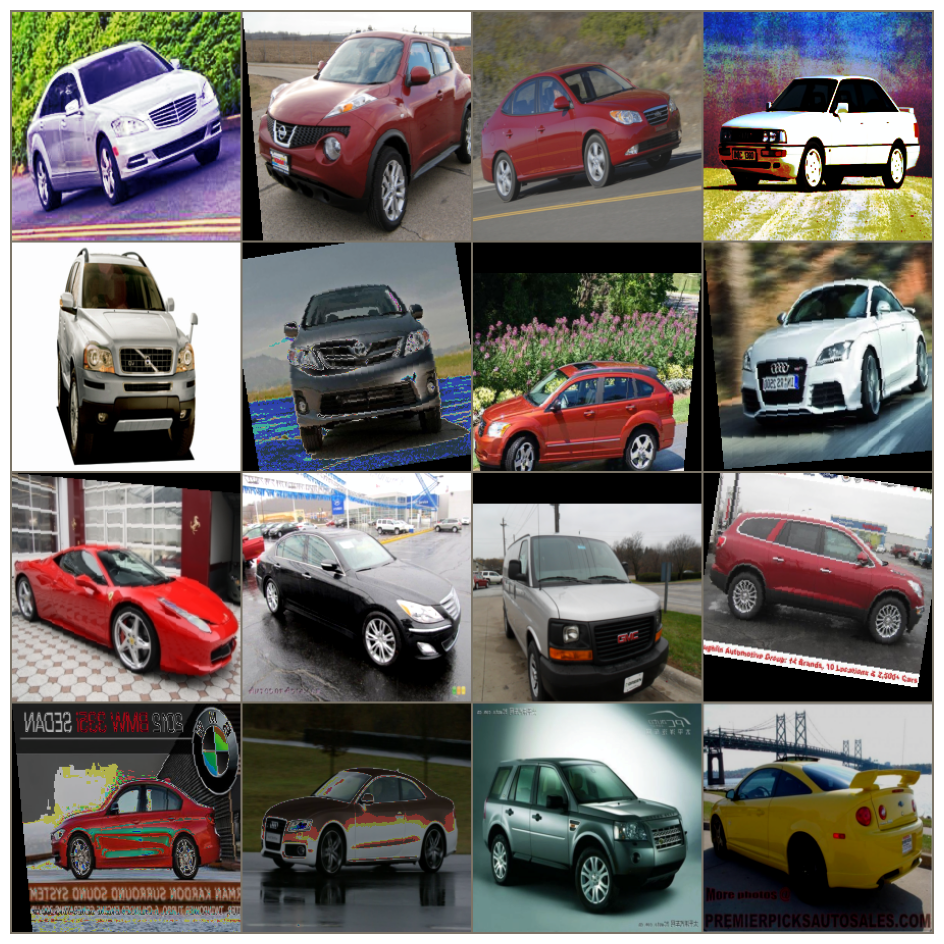

===== 4x4 이미지 정답 (순서대로) =====
Row 1: ['Mercedes-Benz S-Class Sedan 2012', 'Nissan Juke Hatchback 2012', 'Hyundai Elantra Sedan 2007', 'Audi V8 Sedan 1994']
Row 2: ['Volvo XC90 SUV 2007', 'Toyota Corolla Sedan 2012', 'Dodge Caliber Wagon 2007', 'Audi TT Hatchback 2011']
Row 3: ['Ferrari 458 Italia Coupe 2012', 'Hyundai Genesis Sedan 2012', 'GMC Savana Van 2012', 'Buick Enclave SUV 2012']
Row 4: ['BMW 3 Series Sedan 2012', 'Audi A5 Coupe 2012', 'Land Rover LR2 SUV 2012', 'Chevrolet Cobalt SS 2010']


In [ ]:
# 4x4 Grid 시각화

import matplotlib.pyplot as plt
import numpy as np
import torchvision

dataiter = iter(train_loader)
images, labels = next(dataiter)

# 이미지 시각화를 위한 함수 정의
def imshow(img_tensor, title=None):
    # 정규화 복원
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    # 그림 크기 키우기
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

# 이미지 Grid 만들기
# 16개 선택 (:16), 한 줄에 4개씩 배치 (nrow=4)
img_grid = torchvision.utils.make_grid(images[:16], nrow=4, padding=2)

# 이미지 출력
imshow(img_grid.cpu())

# 정답 출력(4x4)
print("===== 4x4 이미지 정답 (순서대로) =====")
for i in range(0, 16, 4):
    row_labels = [class_names[labels[j]] for j in range(i, i+4)]
    print(f"Row {i//4 + 1}: {row_labels}")

In [ ]:
torch.save(model.state_dict(), "car_classifier.pth")


NameError: name 'model' is not defined